# 🫀 Heart Disease — Reproducible Clinical Data Analysis & Modeling

**Dr. Natheer Soliman, MD**  
Healthcare Data Analyst | Clinical Data & AI

This notebook provides a reproducible workflow for exploratory analysis and baseline classification using the processed heart-disease dataset in this repository.

> **Important:** This is an educational portfolio project. Model outputs are not a medical diagnosis and require external validation before any clinical use.


## 1. Setup

The notebook uses repository-relative paths first so it can run from GitHub, Jupyter, or a cloned repository. A Google Colab fallback is included for convenience.


In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report,
    ConfusionMatrixDisplay, RocCurveDisplay
)

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)
RANDOM_STATE = 42


## 2. Load the data

The repository contains `heart_processed.csv`, which is already one-hot encoded. We still perform data-quality checks before modeling.


In [2]:
candidate_paths = [Path("heart_processed.csv"), Path("/content/heart_processed.csv")]
DATA_PATH = next((p for p in candidate_paths if p.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError(
        "heart_processed.csv was not found. Run the notebook from the repository root "
        "or upload the CSV to /content when using Google Colab."
    )

df = pd.read_csv(DATA_PATH)
print(f"Loaded: {DATA_PATH}")
print(f"Shape: {df.shape}")
display(df.head())


Loaded: heart_processed.csv
Shape: (918, 16)
   Age  RestingBP  Cholesterol  FastingBS  MaxHR  Oldpeak  HeartDisease  \
0   40        140          289          0    172      0.0             0   
1   49        160          180          0    156      1.0             1   
2   37        130          283          0     98      0.0             0   
3   48        138          214          0    108      1.5             1   
4   54        150          195          0    122      0.0             0   

   Sex_M  ChestPainType_ATA  ChestPainType_NAP  ChestPainType_TA  \
0   True               True              False             False   
1  False              False               True             False   
2   True               True              False             False   
3  False              False              False             False   
4   True              False               True             False   

   RestingECG_Normal  RestingECG_ST  ExerciseAngina_Y  ST_Slope_Flat  \
0               True   

## 3. Data quality audit

Two fields require special attention in this dataset:

- `Cholesterol = 0` is treated as an implausible/missing measurement rather than a physiological value.
- `RestingBP = 0` is also treated as an implausible/missing measurement.

These values are converted to `NaN`. **Imputation is fitted only on the training data inside the modeling pipeline**, which prevents information from the test set leaking into preprocessing.


In [3]:
print("Data types:")
display(df.dtypes.to_frame("dtype"))

print("\nMissing values before clinical validity checks:")
display(df.isna().sum().to_frame("missing"))

print(f"Duplicate rows: {df.duplicated().sum()}")
for col in ["RestingBP", "Cholesterol"]:
    if col in df.columns:
        print(f"{col} == 0: {(df[col] == 0).sum()}")


Data types:
                     dtype
Age                  int64
RestingBP            int64
Cholesterol          int64
FastingBS            int64
MaxHR                int64
Oldpeak            float64
HeartDisease         int64
Sex_M                 bool
ChestPainType_ATA     bool
ChestPainType_NAP     bool
ChestPainType_TA      bool
RestingECG_Normal     bool
RestingECG_ST         bool
ExerciseAngina_Y      bool
ST_Slope_Flat         bool
ST_Slope_Up           bool

Missing values before clinical validity checks:
                   missing
Age                      0
RestingBP                0
Cholesterol              0
FastingBS                0
MaxHR                    0
Oldpeak                  0
HeartDisease             0
Sex_M                    0
ChestPainType_ATA        0
ChestPainType_NAP        0
ChestPainType_TA         0
RestingECG_Normal        0
RestingECG_ST            0
ExerciseAngina_Y         0
ST_Slope_Flat            0
ST_Slope_Up              0
Duplicate rows: 0
Res

In [4]:
clean_df = df.copy()
for col in ["RestingBP", "Cholesterol"]:
    if col in clean_df.columns:
        clean_df[col] = clean_df[col].replace(0, np.nan)

print("Missing values after converting implausible zeros to NaN:")
display(clean_df.isna().sum().loc[lambda s: s > 0].to_frame("missing"))


Missing values after converting implausible zeros to NaN:
             missing
RestingBP          1
Cholesterol      172


## 4. Descriptive statistics


In [5]:
numeric_summary_cols = [
    col for col in ["Age", "RestingBP", "Cholesterol", "MaxHR", "Oldpeak"]
    if col in clean_df.columns
]
summary = clean_df[numeric_summary_cols].describe().T
summary["median"] = clean_df[numeric_summary_cols].median()
display(summary[["count", "mean", "std", "min", "25%", "median", "75%", "max"]])


             count        mean        std   min     25%  median    75%    max
Age          918.0   53.510893   9.432617  28.0   47.00    54.0   60.0   77.0
RestingBP    917.0  132.540894  17.999749  80.0  120.00   130.0  140.0  200.0
Cholesterol  746.0  244.635389  59.153524  85.0  207.25   237.0  275.0  603.0
MaxHR        918.0  136.809368  25.460334  60.0  120.00   138.0  156.0  202.0
Oldpeak      918.0    0.887364   1.066570  -2.6    0.00     0.6    1.5    6.2


## 5. Exploratory data analysis

The plots below describe the dataset only. They should not be interpreted as causal relationships.


              count  percent
HeartDisease                
0               410    44.66
1               508    55.34


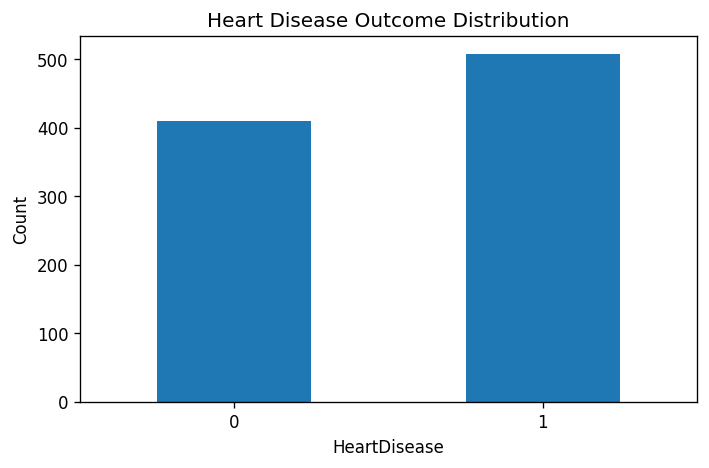

In [6]:
if "HeartDisease" not in clean_df.columns:
    raise KeyError("Expected target column 'HeartDisease' was not found.")

target_counts = clean_df["HeartDisease"].value_counts().sort_index()
target_pct = clean_df["HeartDisease"].value_counts(normalize=True).sort_index().mul(100)
target_table = pd.DataFrame({"count": target_counts, "percent": target_pct.round(2)})
display(target_table)

ax = target_counts.plot(kind="bar", figsize=(6, 4))
ax.set_title("Heart Disease Outcome Distribution")
ax.set_xlabel("HeartDisease")
ax.set_ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


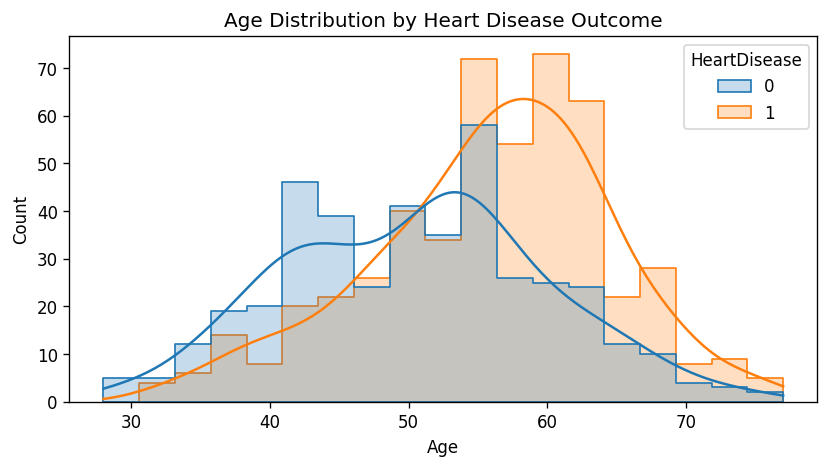

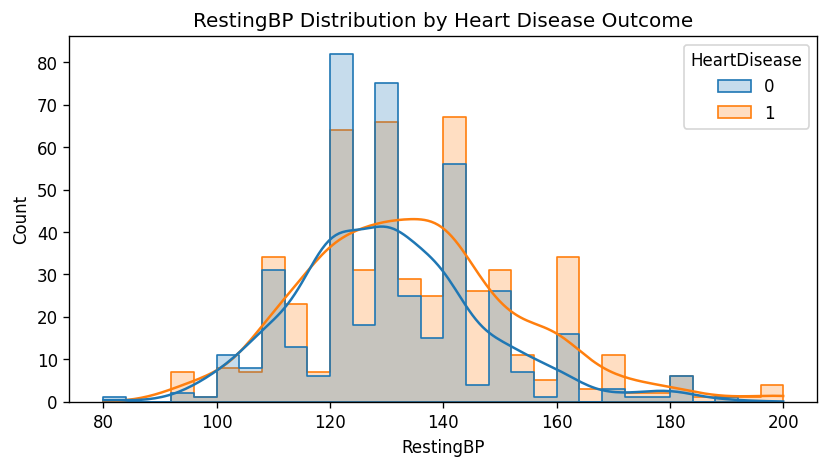

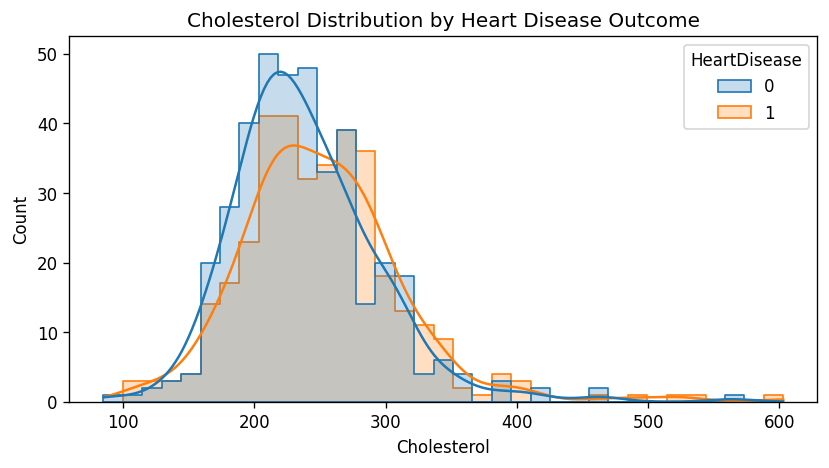

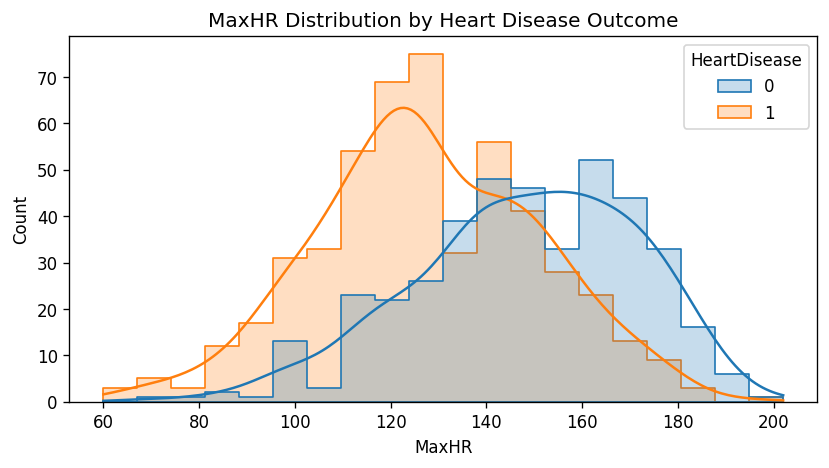

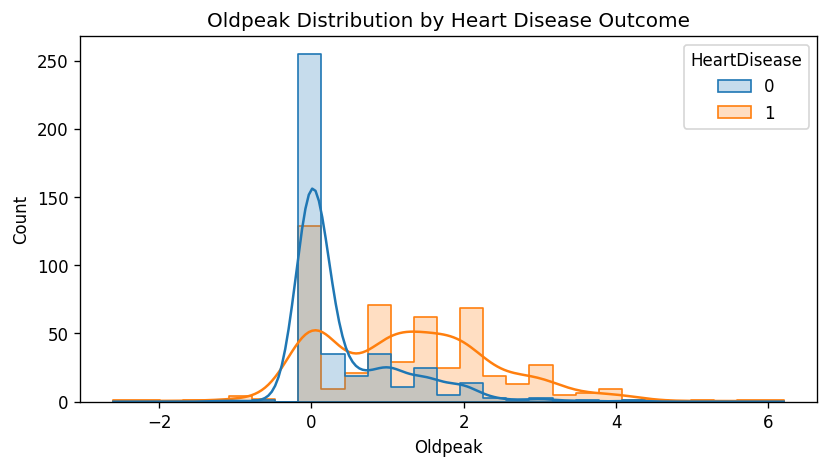

In [7]:
eda_cols = [c for c in ["Age", "RestingBP", "Cholesterol", "MaxHR", "Oldpeak"] if c in clean_df.columns]
for col in eda_cols:
    plt.figure(figsize=(7, 4))
    sns.histplot(data=clean_df, x=col, hue="HeartDisease", kde=True, element="step")
    plt.title(f"{col} Distribution by Heart Disease Outcome")
    plt.tight_layout()
    plt.show()


                   correlation_with_HeartDisease
ST_Slope_Up                            -0.622164
ST_Slope_Flat                           0.554134
ExerciseAngina_Y                        0.494282
Oldpeak                                 0.403951
ChestPainType_ATA                      -0.401924
MaxHR                                  -0.400421
Sex_M                                   0.305445
Age                                     0.282039
FastingBS                               0.267291
ChestPainType_NAP                      -0.212964
RestingBP                               0.117990
Cholesterol                             0.103866
RestingECG_ST                           0.102527
RestingECG_Normal                      -0.091580
ChestPainType_TA                       -0.054790


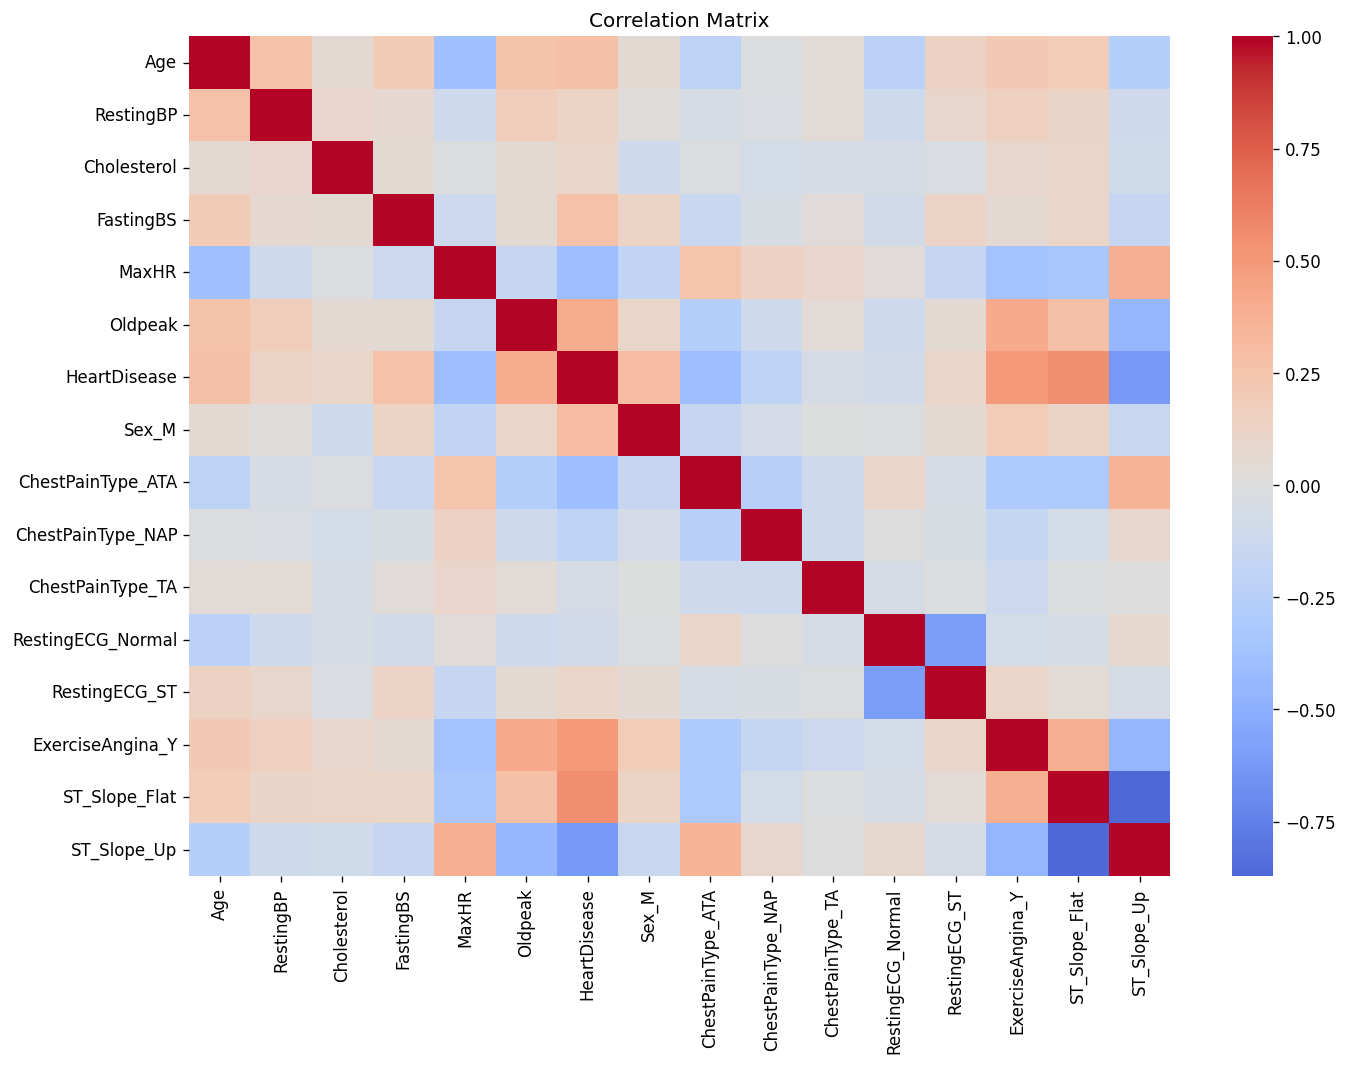

In [8]:
corr = clean_df.select_dtypes(include=[np.number, "bool"]).astype(float).corr()
plt.figure(figsize=(12, 9))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

target_corr = corr["HeartDisease"].drop("HeartDisease").sort_values(key=np.abs, ascending=False)
display(target_corr.to_frame("correlation_with_HeartDisease"))


## 6. Train/test split — before imputation and scaling

The target is separated first, then the data are split using stratification. All learned preprocessing steps are fitted only from `X_train`.


In [9]:
X = clean_df.drop(columns="HeartDisease")
y = clean_df["HeartDisease"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)
print("Training shape:", X_train.shape)
print("Test shape:", X_test.shape)
display(y_train.value_counts(normalize=True).sort_index().mul(100).round(2).to_frame("percent"))


Training shape: (734, 15)
Test shape: (184, 15)
              percent
HeartDisease         
0               44.69
1               55.31


## 7. Baseline models

### Logistic Regression
Median imputation and standardization are learned from the training set only.

### Random Forest
Median imputation is used, but scaling is deliberately omitted because tree-based models do not require standardized feature scales.


In [10]:
logistic_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),
])

rf_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestClassifier(
        n_estimators=300, random_state=RANDOM_STATE, class_weight="balanced", n_jobs=-1
    )),
])

models = {"Logistic Regression": logistic_pipeline, "Random Forest": rf_pipeline}
for model in models.values():
    model.fit(X_train, y_train)
print("Models trained successfully.")


Models trained successfully.


## 8. Hold-out test evaluation

Because this is a healthcare classification problem, the notebook reports more than accuracy. Recall, precision, F1, ROC-AUC, and confusion matrices are included.



=== Logistic Regression ===
              precision    recall  f1-score   support

           0      0.887     0.866     0.877        82
           1      0.894     0.912     0.903       102

    accuracy                          0.891       184
   macro avg      0.891     0.889     0.890       184
weighted avg      0.891     0.891     0.891       184


=== Random Forest ===
              precision    recall  f1-score   support

           0      0.824     0.854     0.838        82
           1      0.879     0.853     0.866       102

    accuracy                          0.853       184
   macro avg      0.851     0.853     0.852       184
weighted avg      0.854     0.853     0.853       184

                     Accuracy  Precision  Recall     F1  ROC_AUC
Model                                                           
Logistic Regression     0.891      0.894   0.912  0.903    0.933
Random Forest           0.853      0.879   0.853  0.866    0.928


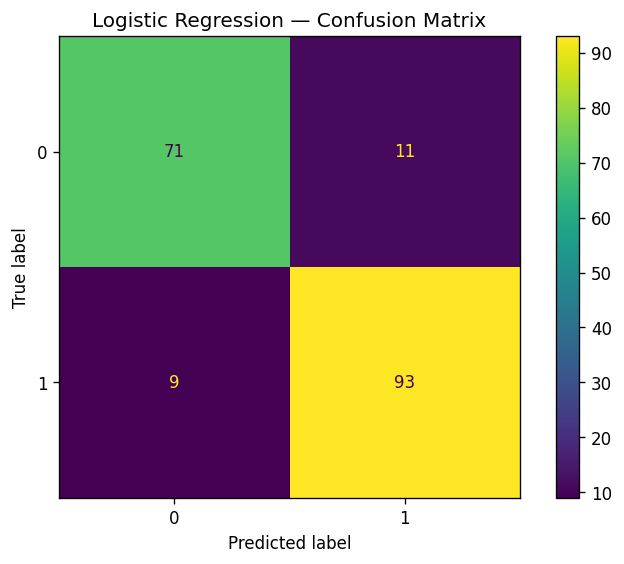

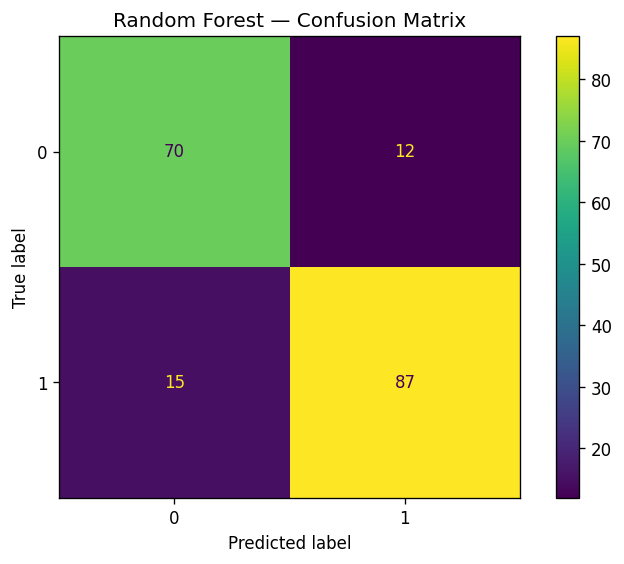

In [11]:
def evaluate_model(name, model, X_eval, y_eval):
    pred = model.predict(X_eval)
    prob = model.predict_proba(X_eval)[:, 1]
    metrics = {
        "Model": name,
        "Accuracy": accuracy_score(y_eval, pred),
        "Precision": precision_score(y_eval, pred, zero_division=0),
        "Recall": recall_score(y_eval, pred, zero_division=0),
        "F1": f1_score(y_eval, pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y_eval, prob),
    }
    print(f"\n=== {name} ===")
    print(classification_report(y_eval, pred, digits=3, zero_division=0))
    ConfusionMatrixDisplay.from_predictions(y_eval, pred)
    plt.title(f"{name} — Confusion Matrix")
    plt.tight_layout()
    plt.show()
    return metrics

results = [evaluate_model(name, model, X_test, y_test) for name, model in models.items()]
results_df = pd.DataFrame(results).set_index("Model").round(3)
display(results_df)


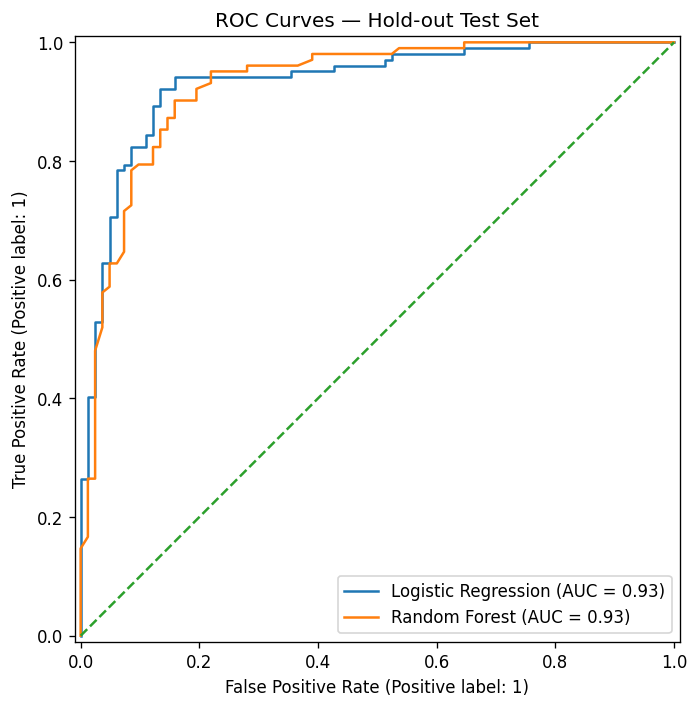

In [12]:
fig, ax = plt.subplots(figsize=(7, 6))
for name, model in models.items():
    RocCurveDisplay.from_estimator(model, X_test, y_test, name=name, ax=ax)
ax.plot([0, 1], [0, 1], linestyle="--")
ax.set_title("ROC Curves — Hold-out Test Set")
plt.tight_layout()
plt.show()


## 9. Stratified cross-validation

A single train/test split can be noisy. Five-fold stratified cross-validation provides a more stable estimate of baseline performance. The entire preprocessing pipeline is evaluated inside each fold, so imputation and scaling remain leakage-safe.


In [13]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
}
cv_rows = []
for name, model in models.items():
    scores = cross_validate(model, X, y, cv=cv, scoring=scoring, n_jobs=-1, error_score="raise")
    row = {"Model": name}
    for metric in scoring:
        values = scores[f"test_{metric}"]
        row[f"{metric}_mean"] = values.mean()
        row[f"{metric}_std"] = values.std()
    cv_rows.append(row)
cv_results = pd.DataFrame(cv_rows).set_index("Model").round(3)
display(cv_results)


                     accuracy_mean  accuracy_std  precision_mean  \
Model                                                              
Logistic Regression          0.857         0.023           0.863   
Random Forest                0.871         0.037           0.866   

                     precision_std  recall_mean  recall_std  f1_mean  f1_std  \
Model                                                                          
Logistic Regression          0.031        0.884       0.040    0.873   0.021   
Random Forest                0.047        0.912       0.031    0.887   0.031   

                     roc_auc_mean  roc_auc_std  
Model                                           
Logistic Regression         0.921        0.020  
Random Forest               0.921        0.029  


## 10. Random Forest feature importance

Feature importance can indicate which variables the fitted tree ensemble relied on most, but it does **not** establish causation or clinical importance.


                   importance
ST_Slope_Up          0.166054
MaxHR                0.118382
Oldpeak              0.114563
ST_Slope_Flat        0.114193
Age                  0.083067
Cholesterol          0.081656
ExerciseAngina_Y     0.080851
RestingBP            0.073271
Sex_M                0.036200
ChestPainType_ATA    0.035956
ChestPainType_NAP    0.030266
FastingBS            0.028431
RestingECG_Normal    0.015653
ChestPainType_TA     0.011615
RestingECG_ST        0.009842


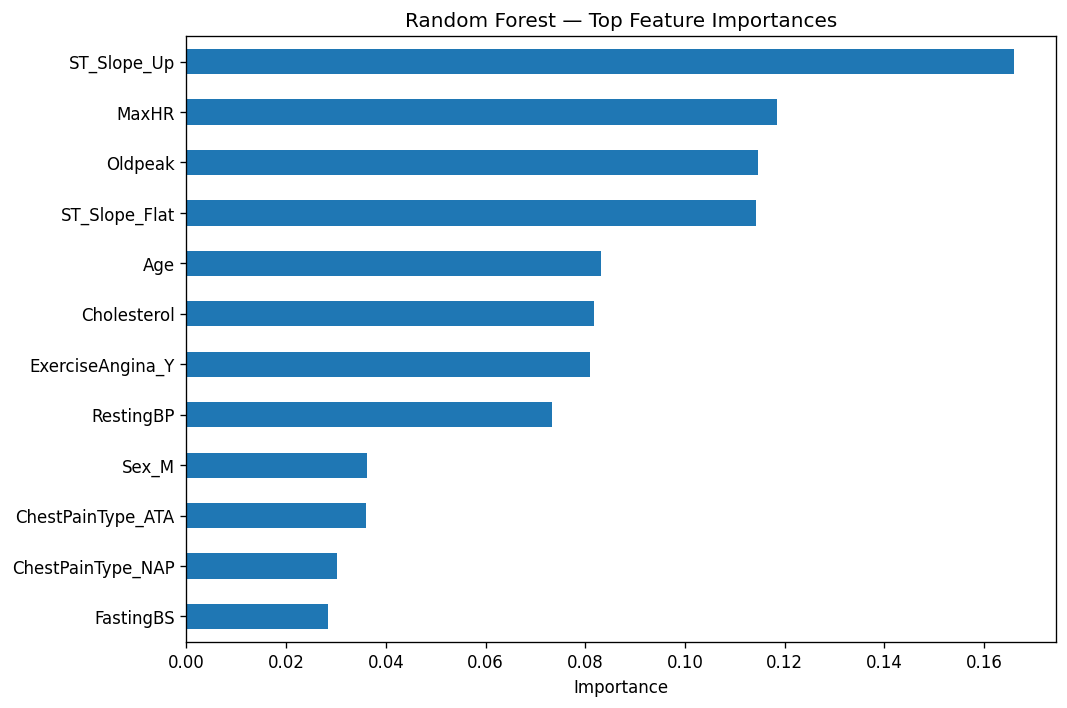

In [14]:
rf_model = rf_pipeline.named_steps["model"]
importance = pd.Series(rf_model.feature_importances_, index=X.columns, name="importance").sort_values(ascending=False)
display(importance.to_frame())
importance.head(12).sort_values().plot(kind="barh", figsize=(9, 6))
plt.title("Random Forest — Top Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()


## 11. Interpretation checklist

When reviewing the executed results:

- Prefer **ROC-AUC, recall, precision, and F1** alongside accuracy.
- Inspect the confusion matrix to understand false negatives and false positives.
- Compare hold-out results with cross-validation results; large differences can indicate instability.
- Do not interpret correlation or feature importance as causation.
- Do not use this model for clinical decision-making without external validation, calibration assessment, bias/fairness review, and clinical governance.

### Portfolio conclusion

This notebook demonstrates a leakage-aware and reproducible healthcare machine-learning workflow using repository-relative data loading, clinically informed validity checks, train-only preprocessing, stratified evaluation, multiple performance metrics, and cross-validation.
